# Objective

The goal of this notebook is to transition from intuition-driven feature selection to a systematic signal discovery process. 

I will generate structured families of candidate signals, evaluate their predictive power using data-driven metrics, and identify a small set of statistically robust signals. 

Only signals that demonstrate consistent and meaningful predictive strength will be selected for further modeling and backtesting.

In [9]:
from __future__ import annotations

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from src.signals import (build_signal_library,
                         select_signals,
                         signal_library_to_long,
                         get_available_signals)
from src.scoring import ( make_forward_returns,
                         score_signal_library,
                         summarize_signal_names)
from src.data_loader import (split_features_target, 
                             make_time_split_index, 
                             split_features_target,
                             split_by_index,
                             get_benchmark_returns)
from src.backtest import (generate_positions_from_proba,
                          strategy_returns_from_positions,
                          cumulative_returns,
                          evaluate_strategy,
                          backtest_continuous_strategy)
from src.utils import (generate_rolling_windows,
                       compute_ic_weights,
                       build_weighted_alpha_rank,
                       build_context_rank)

## 1. Re-download data from yfinance

In [10]:
project_root = Path.cwd().parent
nb02_path = project_root / "data" / "processed" / "notebook_02_data_prep"
nb05_path = project_root / "data" / "processed" / "notebook_05_model_outputs"
ML_dataset = pd.read_csv(nb05_path / "ML_dataset.csv", index_col=0)
clean_close_prices = pd.read_csv(nb02_path / "clean_close_prices.csv", index_col=0)
clean_close_prices.index = pd.to_datetime(clean_close_prices.index)
tickers = clean_close_prices.columns.tolist()
raw_data = yf.download(tickers=tickers,
                       start=clean_close_prices.index.min().strftime("%Y-%m-%d"),
                       end=(clean_close_prices.index.max()+pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
                       auto_adjust=False,
                       progress=False)
volume = raw_data["Volume"].copy()
volume = volume.reindex(index=clean_close_prices.index, columns=clean_close_prices.columns)
volume = volume.replace(0,np.nan)
volume.isna().mean().sort_values(ascending=False).head()
print(volume.shape)

(2080, 31)


## 2. Build signal library

In [11]:
returns = clean_close_prices.pct_change().replace([np.inf, -np.inf], np.nan)
signal_library = build_signal_library(clean_close_prices=clean_close_prices, returns=returns,
                                      volume=volume, benchmark_ticker="SPY", windows=[3, 5, 10, 20, 60])
print(signal_library.shape)
print(signal_library.columns.names)
print(get_available_signals(signal_library)[:10])


(2080, 3840)
['ticker', 'signal']
['accel_10', 'accel_20', 'accel_3', 'accel_5', 'accel_60', 'breakout_dn_10', 'breakout_dn_20', 'breakout_dn_3', 'breakout_dn_5', 'breakout_dn_60']


## 3. Signal predictive power evaluation (1d)

In [12]:
forward_returns_1d = make_forward_returns(clean_close_prices=clean_close_prices,
                                          horizon=1)
scores_1d = score_signal_library(signal_library=signal_library,
                                 forward_returns=forward_returns_1d,
                                 min_obs=60)
signal_summary_1d = summarize_signal_names(scores=scores_1d,
                                           min_obs=60)
strong_signal_1d = signal_summary_1d[(signal_summary_1d["n_ticker_signal_pairs"]>=5) & (signal_summary_1d["mean_ic"]>0.01) & (signal_summary_1d["mean_spread"]>0)].copy()
strong_signal_1d.head(30)

,signal,n_ticker_signal_pairs,mean_ic,median_ic,mean_hit_rate,mean_spread,median_spread
0,breakout_dn_60,30,0.037466,0.039829,0.539467,0.000138,0.000133
1,rev_5,30,0.030459,0.022763,0.501761,0.001146,0.000872
2,breakout_dn_20,30,0.028153,0.025684,0.534996,0.000170,0.000136
3,mkt_regime_vol_60,30,0.026400,0.033566,0.531094,0.000820,0.000979
4,mkt_regime_vol_20,30,0.024936,0.025901,0.530329,0.001013,0.000965
5,vol_60,30,0.022598,0.022263,0.531094,0.000820,0.000449
6,volavg_60,30,0.020375,0.021645,0.531244,0.001085,0.001116
7,volavg_20,30,0.020184,0.022334,0.530379,0.000903,0.000904
8,breakout_dn_10,30,0.019947,0.017251,0.534259,0.000153,0.000135
9,breakout_dn_5,30,0.019380,0.017605,0.537715,0.000533,0.000492


In [13]:
scores_1d.head(20)

,ticker,signal,n_obs,ic,hit_rate,signal_std,fwd_ret_mean,top_bucket_mean,bottom_bucket_mean,spread_top_minus_bottom
0,MA,breakout_dn_60,2079,0.095424,0.623188,1.791730e-01,0.000766,0.000766,0.000448,0.000318
1,MA,rev_5,2073,0.094994,0.516425,3.694209e-02,0.000743,0.002703,-0.000377,0.003080
2,MSFT,breakout_dn_20,2079,0.093261,0.598802,2.718643e-01,0.000923,0.000923,0.000429,0.000495
3,V,rev_5,2073,0.078773,0.511864,3.274047e-02,0.000621,0.001902,0.000038,0.001864
4,MSFT,breakout_dn_3,2079,0.076910,0.574109,4.370034e-01,0.000923,0.003271,0.000112,0.003159
5,MSFT,breakout_dn_10,2079,0.075626,0.543478,3.393926e-01,0.000923,0.000923,0.000392,0.000531
6,PG,rev_5,2073,0.074752,0.508260,2.541372e-02,0.000408,0.001094,0.000187,0.000906
7,MSFT,breakout_dn_60,2079,0.073323,0.571429,1.888980e-01,0.000923,0.000923,0.000665,0.000258
8,V,breakout_dn_5,2079,0.072113,0.593264,3.897065e-01,0.000638,0.000638,0.000076,0.000562
9,PG,rev_3,2075,0.071937,0.511876,2.061137e-02,0.000401,0.001839,-0.000553,0.002391


## 4. Signal predictive power evaluation (Multiple Horizons)

In [14]:
horizons = [1, 3, 5, 10]
horizon_summaries = {}
for h in horizons:
    print(f"\n===== Horizon {h} =====")
    fwd_returns = make_forward_returns(clean_close_prices=clean_close_prices, horizon=h)
    scores = score_signal_library(signal_library=signal_library, forward_returns=fwd_returns, min_obs=60)
    summary = summarize_signal_names(scores=scores, min_obs=60)
    horizon_summaries[h] = summary
    display(summary.head(15))


===== Horizon 1 =====


,signal,n_ticker_signal_pairs,mean_ic,median_ic,mean_hit_rate,mean_spread,median_spread
0,breakout_dn_60,30,0.037466,0.039829,0.539467,0.000138,0.000133
1,rev_5,30,0.030459,0.022763,0.501761,0.001146,0.000872
2,breakout_dn_20,30,0.028153,0.025684,0.534996,0.000170,0.000136
3,mkt_regime_vol_60,30,0.026400,0.033566,0.531094,0.000820,0.000979
4,mkt_regime_vol_20,30,0.024936,0.025901,0.530329,0.001013,0.000965
5,vol_60,30,0.022598,0.022263,0.531094,0.000820,0.000449
6,volavg_60,30,0.020375,0.021645,0.531244,0.001085,0.001116
7,volavg_20,30,0.020184,0.022334,0.530379,0.000903,0.000904
8,breakout_dn_10,30,0.019947,0.017251,0.534259,0.000153,0.000135
9,breakout_dn_5,30,0.019380,0.017605,0.537715,0.000533,0.000492



===== Horizon 3 =====


,signal,n_ticker_signal_pairs,mean_ic,median_ic,mean_hit_rate,mean_spread,median_spread
0,rev_5,30,0.046834,0.037707,0.498539,0.002700,0.002715
1,mkt_regime_vol_60,30,0.046240,0.057496,0.550677,0.002922,0.002776
2,mkt_regime_vol_20,30,0.045963,0.047627,0.548783,0.003683,0.003676
3,rev_3,30,0.044795,0.039794,0.500822,0.002794,0.002618
4,vol_60,30,0.040307,0.039820,0.550677,0.002592,0.001974
5,volavg_20,30,0.034845,0.037718,0.548581,0.002270,0.002119
6,volavg_60,30,0.034362,0.039191,0.550751,0.002762,0.003046
7,vol_20,30,0.032962,0.023979,0.548783,0.001456,0.001156
8,breakout_dn_60,30,0.030084,0.027958,0.574115,0.000182,0.000161
9,mkt_regime_vol_10,30,0.028917,0.028093,0.548830,0.004303,0.003963



===== Horizon 5 =====


,signal,n_ticker_signal_pairs,mean_ic,median_ic,mean_hit_rate,mean_spread,median_spread
0,mkt_regime_vol_20,30,0.063200,0.065151,0.558869,0.005589,0.005799
1,mkt_regime_vol_60,30,0.060599,0.073248,0.560239,0.004630,0.004126
2,vol_60,30,0.052915,0.052561,0.560239,0.004341,0.002800
3,rev_3,30,0.046483,0.036903,0.497983,0.003640,0.003169
4,volavg_20,30,0.045460,0.050179,0.558630,0.003085,0.002665
5,vol_20,30,0.044966,0.034615,0.558869,0.002243,0.001312
6,volavg_60,30,0.044545,0.052189,0.560391,0.004302,0.004212
7,mkt_regime_vol_10,30,0.042352,0.043731,0.558441,0.006264,0.006445
8,rev_5,30,0.038359,0.034827,0.494929,0.003415,0.003792
9,breakout_dn_60,30,0.035310,0.028887,0.594957,0.000280,0.000213



===== Horizon 10 =====


,signal,n_ticker_signal_pairs,mean_ic,median_ic,mean_hit_rate,mean_spread,median_spread
0,mkt_regime_vol_20,30,0.097360,0.103179,0.576690,0.009827,0.010615
1,mkt_regime_vol_60,30,0.091326,0.112117,0.578524,0.011904,0.012805
2,mkt_regime_vol_10,30,0.082356,0.087026,0.574958,0.009753,0.010366
3,vol_60,30,0.078686,0.072411,0.578524,0.009003,0.007404
4,vol_20,30,0.068580,0.050906,0.576690,0.004771,0.004314
5,volavg_20,30,0.065097,0.068586,0.576441,0.005390,0.005924
6,volavg_60,30,0.063617,0.075298,0.578650,0.008223,0.006713
7,vol_10,30,0.058702,0.044829,0.574958,0.004754,0.002588
8,mkt_regime_vol_5,30,0.053112,0.055521,0.575584,0.007751,0.007428
9,volavg_10,30,0.050529,0.051538,0.575051,0.005546,0.004440


## 5. Identify and keep strong candidates

In [15]:
def stable_signals(horizon_summaries, top_n=20):
    from collections import Counter
    signal_counts = Counter()
    for h, summary in horizon_summaries.items():
        top_signals = summary.head(top_n)["signal"].tolist()
        signal_counts.update(top_signals)
    stable = pd.DataFrame(signal_counts.items(), columns=["signal", "appearances"]).sort_values("appearances", ascending=False)
    return stable

stable_signals = stable_signals(horizon_summaries, top_n=20)
strong_stable = stable_signals[stable_signals["appearances"] >= 3].copy()
final_signals = strong_stable["signal"].tolist()
reduced_library = select_signals(signal_library, final_signals)
print(reduced_library.shape)


(2080, 540)


## 6. Define features/ target and split based on time

In [16]:
train_idx, test_idx = make_time_split_index(clean_close_prices, split_ratio=0.7)
signal_train, signal_test = split_by_index(reduced_library, train_idx, test_idx)
prices_train, prices_test = split_by_index(clean_close_prices, train_idx, test_idx)
print("\nTraining samples:", len(signal_train))
print("Testing samples:", len(signal_test))
print("Training price rows:", len(prices_train))
print("Testing price rows:", len(prices_test))


Training samples: 1456
Testing samples: 624
Training targets: 1456
Testing targets: 624


## 7. Score forward returns

In [17]:
fwd_train = make_forward_returns(prices_train, horizon=1)
fwd_test = make_forward_returns(prices_test, horizon=1)
scores_train = score_signal_library(signal_train, fwd_train, min_obs=60)
summary_train = summarize_signal_names(scores_train, min_obs=60)
scores_test = score_signal_library(signal_test, fwd_test, min_obs=60)
summary_test = summarize_signal_names(scores_test, min_obs=60)
summary_train.head(15)
summary_test.head(15)

,signal,n_ticker_signal_pairs,mean_ic,median_ic,mean_hit_rate,mean_spread,median_spread
0,volavg_3,30,0.038002,0.040303,0.529484,0.001712,0.001317
1,volavg_5,30,0.026094,0.022911,0.529484,0.001320,0.001208
2,volavg_10,30,0.021133,0.023171,0.529484,0.000933,0.000673
3,mkt_regime_vol_20,30,0.019640,0.032677,0.529484,0.001089,0.001285
4,volavg_60,30,0.019153,0.008838,0.529484,0.001063,0.001081
5,rev_3,30,0.017617,0.024242,0.500185,0.000588,0.000709
6,rev_5,30,0.016970,0.013614,0.501185,0.000301,0.000158
7,volavg_20,30,0.016595,0.021693,0.529484,0.000571,0.000905
8,vol_20,30,0.016139,0.017458,0.529484,0.000700,0.001014
9,vol_10,30,0.014701,0.018528,0.529484,0.001056,0.000784


# KEEP TOP-1 SIGNAL PER FAMILY

## 8. Identify survivor signal catalog and roles

In [18]:
def consistent_signals(train_summary, test_summary, top_n=20):
    train_top = set(train_summary.head(top_n)["signal"])
    test_top = set(test_summary.head(top_n)["signal"])
    consistent = list(train_top.intersection(test_top))
    return consistent
final_survivors = consistent_signals(summary_train, summary_test, top_n=20)

def signal_family(signal_name):
    if signal_name.startswith("breakout_dn"):
        return "breakout_dn"
    elif signal_name.startswith("rev"):
        return "reversal"
    elif signal_name.startswith("volavg"):
        return "volavg"
    elif signal_name.startswith("vol_"):
        return "vol"
    elif signal_name.startswith("mkt_regime_vol"):
        return "mkt_vol"
    else:
        return "other"
    
survivors_by_family = summary_train.copy()
survivors_by_family = survivors_by_family[survivors_by_family["signal"].isin(final_survivors)]
survivors_by_family["family"] = survivors_by_family["signal"].apply(signal_family)
best_per_family = (survivors_by_family.sort_values("mean_ic", ascending=False).groupby("family").head(1))

signal_catalog = best_per_family.copy()
def assign_signal_role(row):
    alpha_families = {"reversal", "breakout_dn"}
    context_families = {"vol", "volavg", "mkt_vol"}

    if row["family"] in alpha_families and row["mean_ic"] >= 0.02:
        return "alpha"
    elif row["family"] in context_families:
        return "context"
    else:
        return "other"

signal_catalog["role"] = signal_catalog.apply(assign_signal_role, axis=1)
alpha_signals = signal_catalog.loc[signal_catalog["role"] == "alpha", "signal"].tolist()
context_signals = signal_catalog.loc[signal_catalog["role"] == "context", "signal"].tolist()

## 9. Rebuild signal library

In [19]:
alpha_library = select_signals(signal_library, alpha_signals)
context_library = select_signals(signal_library, context_signals)
robust_library = select_signals(signal_library, alpha_signals + context_signals)
alpha_score = sum(alpha_library.xs(sig, level="signal", axis=1)
    for sig in alpha_signals) / len(alpha_signals)
alpha_rank = alpha_score.rank(axis=1, pct=True)
context_score = sum(context_library.xs(sig, level="signal", axis=1)
    for sig in context_signals) / len(context_signals)
context_rank = context_score.rank(axis=1, pct=True)
context_scale = 1-context_rank

## 10. Trade simulations on test dataset

In [20]:
alpha_library_test = select_signals(signal_test, alpha_signals)
alpha_score_test = sum(alpha_library_test.xs(sig, level="signal", axis=1)
    for sig in alpha_signals) / len(alpha_signals)
alpha_rank_test = alpha_score_test.rank(axis=1, pct=True)
long_test = alpha_rank_test >= 0.8
short_test = alpha_rank_test <= 0.2
positions_test = long_test.astype(int) - short_test.astype(int)
strategy_returns_test = (positions_test.shift(1) * forward_returns_1d).mean(axis=1).dropna()

## 11. Visualize alpha signal performance on test dataset

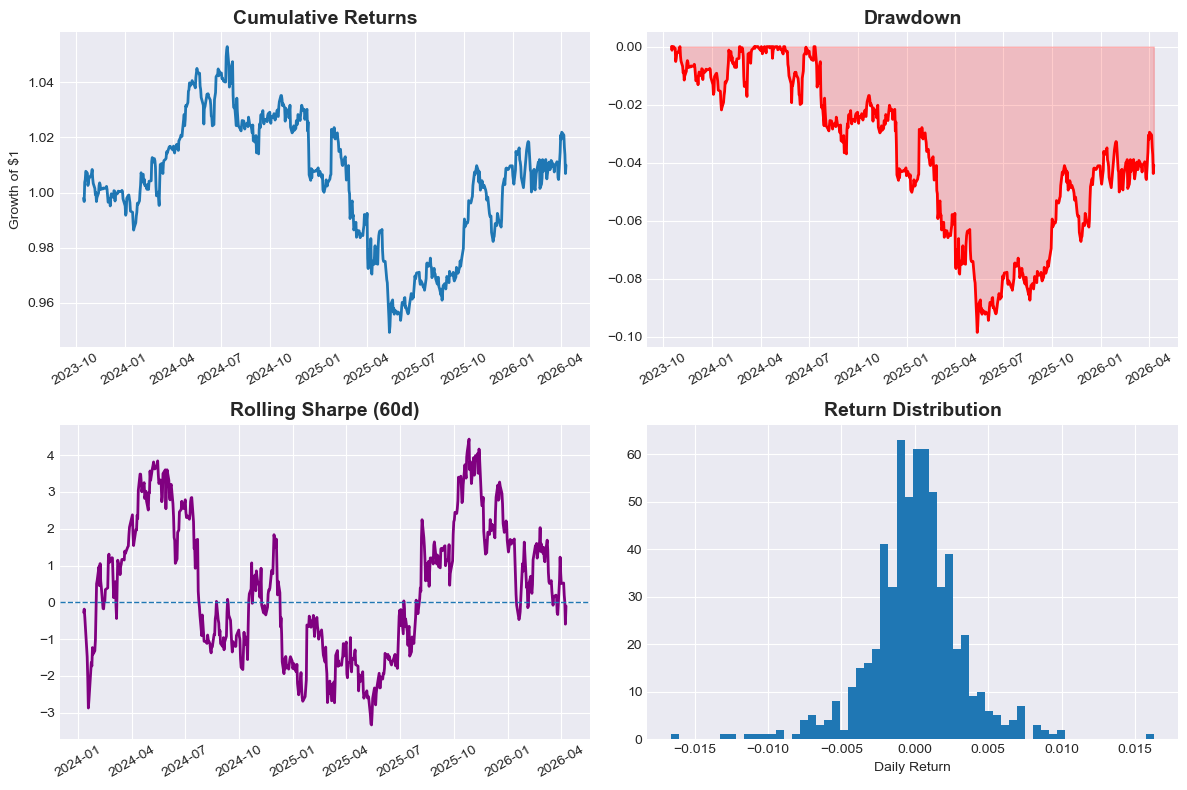

In [21]:

cum_returns = (1 + strategy_returns_test).cumprod()
drawdown = cum_returns / cum_returns.cummax() - 1
rolling_sharpe = (strategy_returns_test.rolling(60).mean() / strategy_returns_test.rolling(60).std()) * np.sqrt(252)

plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
# --- 1. Cumulative Returns ---
axes[0].plot(cum_returns, linewidth=2)
axes[0].set_title("Cumulative Returns", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Growth of $1")
axes[0].tick_params(axis='x', rotation=30)

# --- 2. Drawdown ---
axes[1].plot(drawdown, linewidth=2, color="red")
axes[1].fill_between(drawdown.index, drawdown, 0, alpha=0.2, color="red")
axes[1].set_title("Drawdown", fontsize=14, fontweight="bold")
axes[1].tick_params(axis='x', rotation=30)

# --- 3. Rolling Sharpe ---
axes[2].plot(rolling_sharpe, linewidth=2, color="purple")
axes[2].axhline(0, linestyle="--", linewidth=1)
axes[2].set_title("Rolling Sharpe (60d)", fontsize=14, fontweight="bold")
axes[2].tick_params(axis='x', rotation=30)

# --- 4. Return Distribution ---
axes[3].hist(strategy_returns_test, bins=60)
axes[3].set_title("Return Distribution", fontsize=14, fontweight="bold")
axes[3].set_xlabel("Daily Return")

plt.tight_layout()
plt.show()

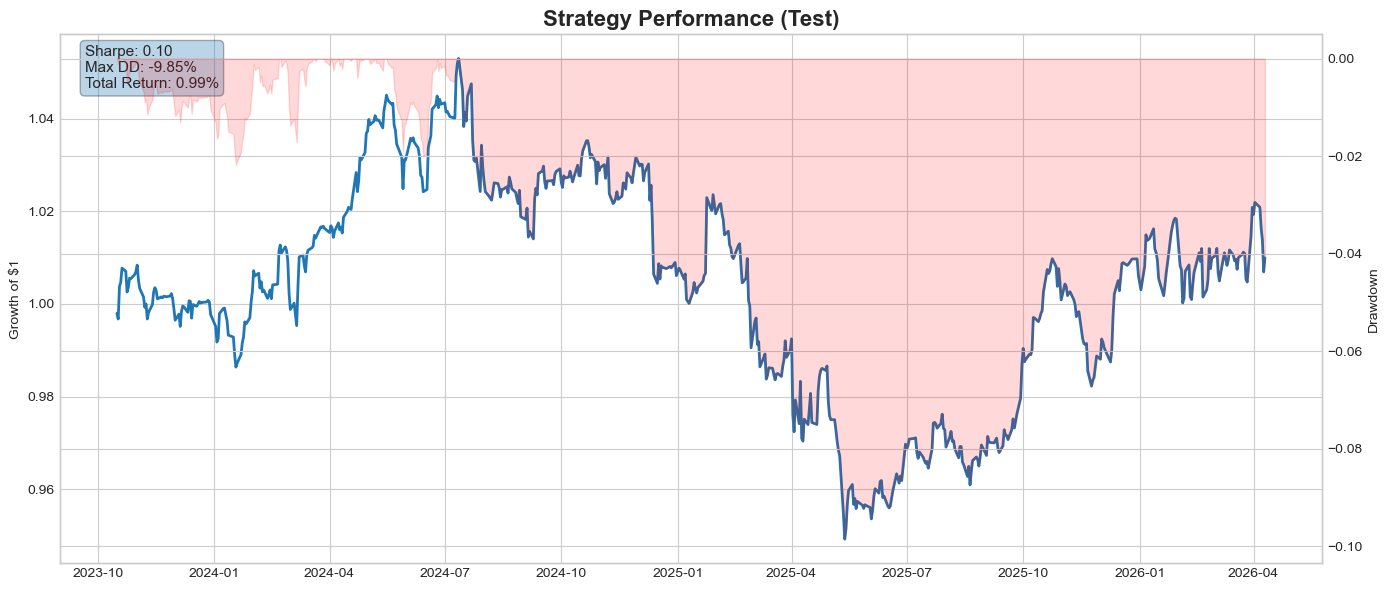

In [22]:
# stats
mean_ret = strategy_returns_test.mean()
std_ret = strategy_returns_test.std()
sharpe = (mean_ret / std_ret) * np.sqrt(252)
max_dd = drawdown.min()
total_return = cum_returns.iloc[-1] - 1

# --- plot ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

# equity curve
ax.plot(cum_returns, linewidth=2)

# drawdown (secondary axis)
ax2 = ax.twinx()
ax2.fill_between(drawdown.index, drawdown, 0, alpha=0.15, color="red")

# titles
ax.set_title("Strategy Performance (Test)", fontsize=16, fontweight="bold")

# labels
ax.set_ylabel("Growth of $1")
ax2.set_ylabel("Drawdown")

# stats box
stats_text = (f"Sharpe: {sharpe:.2f}\n" f"Max DD: {max_dd:.2%}\n" f"Total Return: {total_return:.2%}")

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.3))

plt.tight_layout()
plt.show()

# Midpoint Conclusion - Using only Alpha signals

I have built a complete, clean pipeline from signal generation to out-of-sample backtesting, with proper time-based validation and a reduced set of stable, interpretable signals. 

The baseline long/short strategy confirms that the signals contain some real structure, but the edge is weak and clearly regime-dependent, with modest returns and noticeable drawdowns. 

Going forward, the focus shifts from finding signals to improving how they are used—specifically by incorporating context as a modifier, refining portfolio construction, and adding realism (costs, turnover, robustness testing) to turn this into a more stable and deployable strategy.

## 12. Test trading simulation using context signals

In [23]:
context_library_test = select_signals(signal_test, context_signals)
context_score_test = sum(context_library_test.xs(sig, level="signal", axis=1)
    for sig in context_signals) / len(context_signals)
context_rank_test = context_score_test.rank(axis=1, pct=True)
forward_returns_test_1d = make_forward_returns(prices_test, horizon=1)
forward_returns_test_1d = forward_returns_test_1d.reindex(index=positions_test.index, columns=positions_test.columns)

thresholds = [0.6, 0.7, 0.8, 0.9]
results = []
for th in thresholds:
    good_context = context_rank_test <= th
    positions_filtered = positions_test * good_context.astype(int)
    strat_ret = (positions_filtered.shift(1) * forward_returns_test_1d).mean(axis=1).dropna()
    cum = (1 + strat_ret).cumprod()
    sharpe = (strat_ret.mean() / strat_ret.std()) * np.sqrt(252) if strat_ret.std() != 0 else np.nan
    max_dd = (cum / cum.cummax() - 1).min()
    total_ret = cum.iloc[-1] - 1
    results.append({"threshold": th, "sharpe": sharpe, "max_dd": max_dd, "total_return": total_ret})

results = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print(results)

context_scale = 1 - context_rank_test
positions_scaled = positions_test * context_scale
scaled_returns = (positions_scaled.shift(1) * forward_returns_test_1d).mean(axis=1).dropna()
scaled_cum = (1 + scaled_returns).cumprod()
scaled_sharpe = (scaled_returns.mean() / scaled_returns.std()) * np.sqrt(252) if scaled_returns.std() != 0 else np.nan
scaled_max_dd = (scaled_cum / scaled_cum.cummax() - 1).min()
scaled_total_return = scaled_cum.iloc[-1] - 1
print(f"Scaled Sharpe: {scaled_sharpe:.3f}")
print(f"Scaled Max DD: {scaled_max_dd:.2%}")
print(f"Scaled Total Return: {scaled_total_return:.2%}")

   threshold    sharpe    max_dd  total_return
0        0.6  0.143719 -0.062729      0.009636
2        0.8  0.042986 -0.074856      0.002254
1        0.7  0.027435 -0.067603      0.000882
3        0.9  0.012377 -0.091193     -0.000965
Scaled Sharpe: 0.007
Scaled Max DD: -4.38%
Scaled Total Return: -0.03%


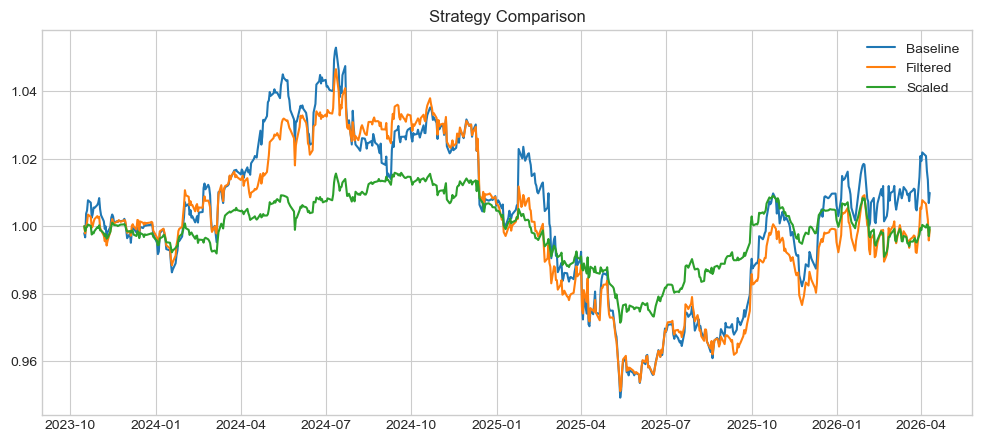

In [24]:
plt.figure(figsize=(12, 5))
plt.plot((1 + strategy_returns_test).cumprod(), label="Baseline")
plt.plot((1 + strat_ret).cumprod(), label="Filtered")
plt.plot(scaled_cum, label="Scaled")
plt.legend()
plt.title("Strategy Comparison")
plt.show()

## 13. Build hybrid filter + mild scaling combo signals

In [25]:
good_context = (context_rank_test <= 0.6).astype(int)
mild_scale = 1 - 0.3 * context_rank_test
positions_hybrid = positions_test * good_context * mild_scale
hybrid_returns = (positions_hybrid.shift(1) * forward_returns_test_1d).mean(axis=1).dropna()
hybrid_cum = (1 + hybrid_returns).cumprod()
hybrid_sharpe = (hybrid_returns.mean() / hybrid_returns.std()) * np.sqrt(252) if hybrid_returns.std() != 0 else np.nan
hybrid_max_dd = (hybrid_cum / hybrid_cum.cummax() - 1).min()
hybrid_total_return = hybrid_cum.iloc[-1] - 1

print(f"Hybrid Sharpe: {hybrid_sharpe:.3f}")
print(f"Hybrid Max DD: {hybrid_max_dd:.2%}")
print(f"Hybrid Total Return: {hybrid_total_return:.2%}")

Hybrid Sharpe: 0.127
Hybrid Max DD: -5.59%
Hybrid Total Return: 0.77%


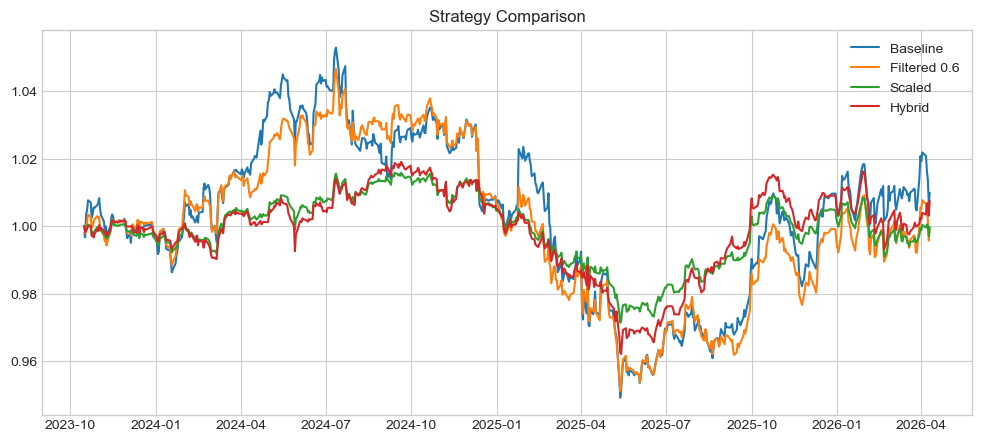

In [26]:
plt.figure(figsize=(12, 5))
plt.plot((1 + strategy_returns_test).cumprod(), label="Baseline")
plt.plot((1 + strat_ret).cumprod(), label="Filtered 0.6")
plt.plot(scaled_cum, label="Scaled")
plt.plot(hybrid_cum, label="Hybrid")
plt.legend()
plt.title("Strategy Comparison")
plt.show()

## 14. Build weighted alpha model using train dataset

In [27]:
weighted_alpha = summary_train[summary_train["signal"].isin(alpha_signals)].copy()
weighted_alpha["raw_weight"] = weighted_alpha["mean_ic"].clip(lower=0)
weighted_alpha["weight"] = (weighted_alpha["raw_weight"] / weighted_alpha["raw_weight"].sum())
alpha_weights = dict(zip(weighted_alpha["signal"], weighted_alpha["weight"]))
weighted_alpha_score_test = sum(alpha_library_test.xs(sig, level="signal", axis=1) * alpha_weights[sig]
    for sig in alpha_signals)
weighted_alpha_rank_test = weighted_alpha_score_test.rank(axis=1, pct=True)
long_w = weighted_alpha_rank_test >= 0.8
short_w = weighted_alpha_rank_test <= 0.2
positions_weighted = long_w.astype(int) - short_w.astype(int)
weighted_returns = (positions_weighted.shift(1) * forward_returns_test_1d).mean(axis=1).dropna()
weighted_cum = (1 + weighted_returns).cumprod()
weighted_sharpe = (weighted_returns.mean() / weighted_returns.std()) * np.sqrt(252) if weighted_returns.std() != 0 else np.nan
weighted_max_dd = (weighted_cum / weighted_cum.cummax() - 1).min()
weighted_total_return = weighted_cum.iloc[-1] - 1
print(f"Weighted Sharpe: {weighted_sharpe:.3f}")
print(f"Weighted Max DD: {weighted_max_dd:.2%}")
print(f"Weighted Return: {weighted_total_return:.2%}")

Weighted Sharpe: 0.104
Weighted Max DD: -9.85%
Weighted Return: 0.99%


In [28]:
positions_weighted_filtered = (positions_weighted * (context_rank_test <= 0.6).astype(int))
weighted_filtered_returns = (positions_weighted_filtered.shift(1) * forward_returns_test_1d).mean(axis=1).dropna()
weighted_filtered_cum = (1 + weighted_filtered_returns).cumprod()
weighted_filtered_sharpe = (weighted_filtered_returns.mean() / weighted_filtered_returns.std()) * np.sqrt(252)
weighted_filtered_max_dd = (weighted_filtered_cum / weighted_filtered_cum.cummax() - 1).min()
weighted_filtered_total_return = weighted_filtered_cum.iloc[-1] - 1
print(f"Weighted+Filtered Sharpe: {weighted_filtered_sharpe:.3f}")
print(f"Weighted+Filtered Max DD: {weighted_filtered_max_dd:.2%}")
print(f"Weighted+Filtered Return: {weighted_filtered_total_return:.2%}")

Weighted+Filtered Sharpe: 0.144
Weighted+Filtered Max DD: -6.27%
Weighted+Filtered Return: 0.96%


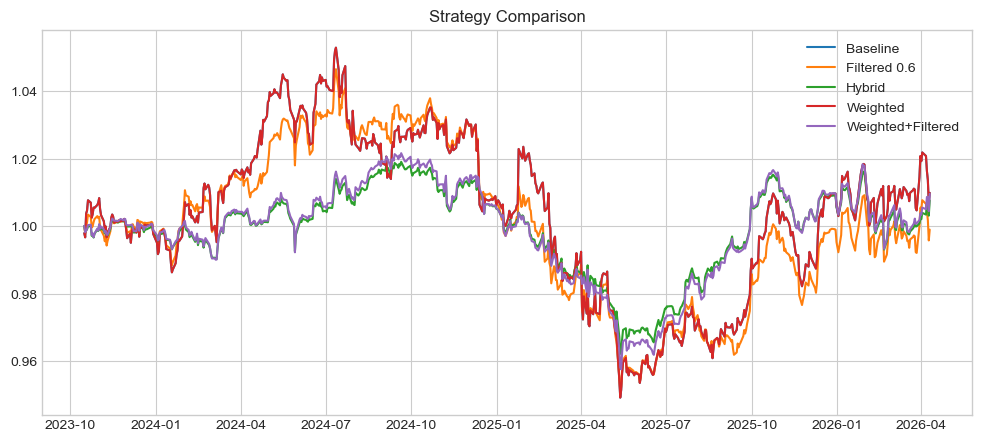

In [29]:
plt.figure(figsize=(12,5))
plt.plot((1 + strategy_returns_test).cumprod(), label="Baseline")
plt.plot((1 + strat_ret).cumprod(), label="Filtered 0.6")
plt.plot(hybrid_cum, label="Hybrid")
plt.plot(weighted_cum, label="Weighted")
plt.plot(weighted_filtered_cum, label="Weighted+Filtered")
plt.legend()
plt.title("Strategy Comparison")
plt.show()

# Midpoint Conclusion 2 - Incorporating context signals into alpha improves performance

I built a systematic signal pipeline by identifying robust signals through multi-horizon forward return testing and filtering out unstable candidates. 

Using a top-1-per-family approach, I constructed a minimal alpha model and evaluated it with time-based out-of-sample testing. Incorporating context signals as a regime filter (threshold ≈ 0.6) significantly improved performance by reducing drawdowns and increasing Sharpe, confirming that my alpha is highly regime-dependent. 

However, attempts to improve performance through scaling or weighting showed little to no benefit, indicating that the current limitation is not signal combination but insufficient alpha diversity. 

The next step is to expand the signal set (top-2 per family) to introduce more variation and allow weighting to become effective.

# EXPAND TO TOP-2 SIGNALS PER FAMILY

## 15. Rebuild survivor signal catalog and roles

In [30]:
survivors_by_family = summary_train.copy()
survivors_by_family = survivors_by_family[survivors_by_family["signal"].isin(final_survivors)]
survivors_by_family["family"] = survivors_by_family["signal"].apply(signal_family)
best_per_family_2 = (survivors_by_family.sort_values("mean_ic", ascending=False).groupby("family").head(2).copy())
signal_catalog_2 = best_per_family_2.copy()
def assign_signal_role(row):
    alpha_families = {"reversal", "breakout_dn"}
    context_families = {"vol", "volavg", "mkt_vol"}
    if row["family"] in alpha_families and row["mean_ic"] >= 0.02:
        return "alpha"
    elif row["family"] in context_families:
        return "context"
    else:
        return "other"
signal_catalog_2["role"] = signal_catalog_2.apply(assign_signal_role, axis=1)
alpha_signals_2 = signal_catalog_2.loc[signal_catalog_2["role"] == "alpha", "signal"].tolist()
context_signals_2 = signal_catalog_2.loc[signal_catalog_2["role"] == "context", "signal"].tolist()
print("Alpha signals:", alpha_signals_2)
print("Context signals:", context_signals_2)

Alpha signals: ['breakout_dn_60', 'breakout_dn_20', 'rev_5']
Context signals: ['volavg_60', 'mkt_regime_vol_60', 'volavg_20', 'mkt_regime_vol_20', 'vol_60', 'vol_20']


## 16. Trade simulations on test dataset

In [31]:
alpha_library_test_2 = select_signals(signal_test, alpha_signals_2)
context_library_test_2 = select_signals(signal_test, context_signals_2)
print(alpha_library_test_2.shape)
print(context_library_test_2.shape)

(624, 90)
(624, 180)


## 17. Equal-weight alpha with expanded set as baseline

In [32]:
alpha_score_test_2 = sum(
    alpha_library_test_2.xs(sig, level="signal", axis=1)
    for sig in alpha_signals_2) / len(alpha_signals_2)
alpha_rank_test_2 = alpha_score_test_2.rank(axis=1, pct=True)
long_test_2 = alpha_rank_test_2 >= 0.8
short_test_2 = alpha_rank_test_2 <= 0.2
positions_test_2 = long_test_2.astype(int) - short_test_2.astype(int)

## 18. Test trading simulation using expanded context signals

In [33]:
context_score_test_2 = sum(
    context_library_test_2.xs(sig, level="signal", axis=1)
    for sig in context_signals_2) / len(context_signals_2)
context_rank_test_2 = context_score_test_2.rank(axis=1, pct=True)
forward_returns_test_1d = make_forward_returns(prices_test, horizon=1)
forward_returns_test_1d = forward_returns_test_1d.reindex(index=positions_test_2.index, columns=positions_test_2.columns)
positions_filtered_2 = positions_test_2 * (context_rank_test_2 <= 0.6).astype(int)
returns_filtered_2 = (positions_filtered_2.shift(1) * forward_returns_test_1d).mean(axis=1).dropna()
cum_filtered_2 = (1 + returns_filtered_2).cumprod()
sharpe_filtered_2 = (returns_filtered_2.mean() / returns_filtered_2.std()) * np.sqrt(252) if returns_filtered_2.std() != 0 else np.nan
max_dd_filtered_2 = (cum_filtered_2 / cum_filtered_2.cummax() - 1).min()
total_ret_filtered_2 = cum_filtered_2.iloc[-1] - 1
print(f"Expanded Equal+Filtered Sharpe: {sharpe_filtered_2:.3f}")
print(f"Expanded Equal+Filtered Max DD: {max_dd_filtered_2:.2%}")
print(f"Expanded Equal+Filtered Return: {total_ret_filtered_2:.2%}")

Expanded Equal+Filtered Sharpe: 0.164
Expanded Equal+Filtered Max DD: -5.75%
Expanded Equal+Filtered Return: 1.06%


## 18. Weighted alpha using expanded set

In [34]:
weighted_alpha_2 = summary_train[summary_train["signal"].isin(alpha_signals_2)].copy()
weighted_alpha_2["raw_weight"] = weighted_alpha_2["mean_ic"].clip(lower=0)
weighted_alpha_2["weight"] = (weighted_alpha_2["raw_weight"] / weighted_alpha_2["raw_weight"].sum())
alpha_weights_2 = dict(zip(weighted_alpha_2["signal"], weighted_alpha_2["weight"]))
print(weighted_alpha_2[["signal", "mean_ic", "weight"]])
weighted_alpha_score_test_2 = sum(alpha_library_test_2.xs(sig, level="signal", axis=1) * alpha_weights_2[sig]
    for sig in alpha_signals_2)
weighted_alpha_rank_test_2 = weighted_alpha_score_test_2.rank(axis=1, pct=True)
long_w_2 = weighted_alpha_rank_test_2 >= 0.8
short_w_2 = weighted_alpha_rank_test_2 <= 0.2
positions_weighted_2 = long_w_2.astype(int) - short_w_2.astype(int)
positions_weighted_filtered_2 = (positions_weighted_2 * (context_rank_test_2 <= 0.6).astype(int))
returns_weighted_filtered_2 = (positions_weighted_filtered_2.shift(1) * forward_returns_test_1d).mean(axis=1).dropna()
cum_weighted_filtered_2 = (1 + returns_weighted_filtered_2).cumprod()
sharpe_weighted_filtered_2 = (returns_weighted_filtered_2.mean() / returns_weighted_filtered_2.std()) * np.sqrt(252) if returns_weighted_filtered_2.std() != 0 else np.nan
max_dd_weighted_filtered_2 = (cum_weighted_filtered_2 / cum_weighted_filtered_2.cummax() - 1).min()
total_ret_weighted_filtered_2 = cum_weighted_filtered_2.iloc[-1] - 1
print(f"Expanded Weighted+Filtered Sharpe: {sharpe_weighted_filtered_2:.3f}")
print(f"Expanded Weighted+Filtered Max DD: {max_dd_weighted_filtered_2:.2%}")
print(f"Expanded Weighted+Filtered Return: {total_ret_weighted_filtered_2:.2%}")

           signal   mean_ic    weight
0  breakout_dn_60  0.051706  0.410966
1  breakout_dn_20  0.037151  0.295281
2           rev_5  0.036959  0.293753
Expanded Weighted+Filtered Sharpe: 0.164
Expanded Weighted+Filtered Max DD: -5.75%
Expanded Weighted+Filtered Return: 1.06%


## 19. Visualize performance Top-1 vs Top-2

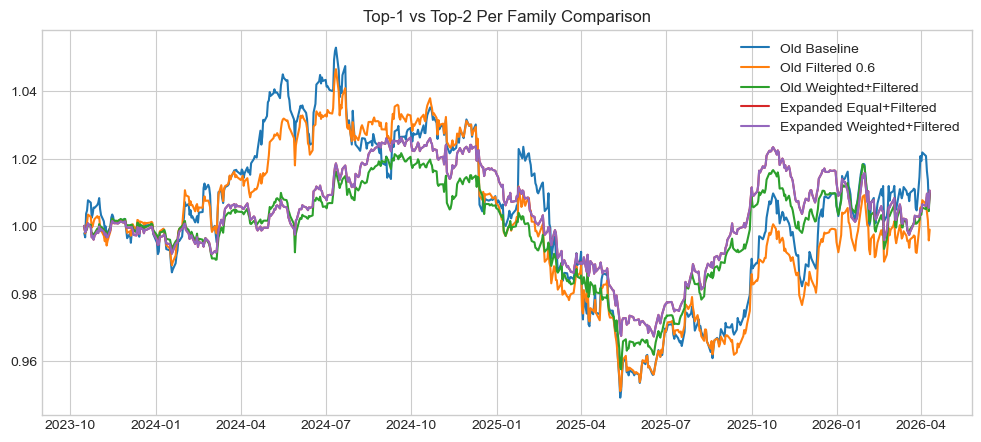

In [35]:
plt.figure(figsize=(12, 5))
plt.plot((1 + strategy_returns_test).cumprod(), label="Old Baseline")
plt.plot((1 + strat_ret).cumprod(), label="Old Filtered 0.6")
plt.plot(weighted_filtered_cum, label="Old Weighted+Filtered")
plt.plot(cum_filtered_2, label="Expanded Equal+Filtered")
plt.plot(cum_weighted_filtered_2, label="Expanded Weighted+Filtered")
plt.legend()
plt.title("Top-1 vs Top-2 Per Family Comparison")
plt.show()

# Midpoint Conclusion 3 - Expanding from Top-1-Alpha per family to Top-2 shows clear improvements

Expanding to a top-2-per-family approach increased alpha diversity by introducing complementary signals within the same families, particularly across different horizons. 

This change led to a clear improvement in Sharpe, drawdown, and total return, demonstrating that the strategy benefits from broader signal representation rather than relying on a single “best” signal per family. With multiple alpha inputs, weighting based on signal strength (IC) became effective for the first time, confirming that portfolio construction matters once sufficient diversity exists. 

The current setup now combines a diversified alpha layer with a robust context filter, forming a stable and improved baseline. 

The next step is to test top-3 per family to determine whether further expansion continues to add value or begins to introduce noise and diminishing returns.

# FURTHUR EXPAND TO TOP-3 SIGNALS PER FAMILY

Top-3 Sharpe: -0.058
Top-3 Max DD: -4.23%
Top-3 Return: -0.48%


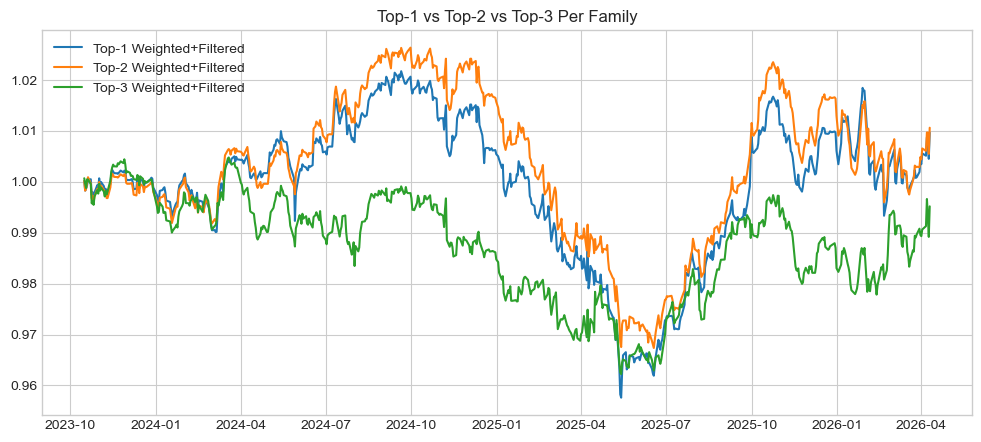

In [36]:
best_per_family_3 = (survivors_by_family.sort_values("mean_ic", ascending=False).groupby("family").head(3).copy())
signal_catalog_3 = best_per_family_3.copy()
signal_catalog_3["role"] = signal_catalog_3.apply(assign_signal_role, axis=1)
alpha_signals_3 = signal_catalog_3.loc[signal_catalog_3["role"] == "alpha", "signal"].tolist()
context_signals_3 = signal_catalog_3.loc[signal_catalog_3["role"] == "context", "signal"].tolist()
alpha_library_test_3 = select_signals(signal_test, alpha_signals_3)
context_library_test_3 = select_signals(signal_test, context_signals_3)
weighted_alpha_3 = summary_train[summary_train["signal"].isin(alpha_signals_3)].copy()
weighted_alpha_3["raw_weight"] = weighted_alpha_3["mean_ic"].clip(lower=0)
weighted_alpha_3["weight"] = (weighted_alpha_3["raw_weight"] / weighted_alpha_3["raw_weight"].sum())
alpha_weights_3 = dict(zip(weighted_alpha_3["signal"], weighted_alpha_3["weight"]))
weighted_alpha_score_test_3 = sum(alpha_library_test_3.xs(sig, level="signal", axis=1) * alpha_weights_3[sig]
    for sig in alpha_signals_3)
alpha_rank_test_3 = weighted_alpha_score_test_3.rank(axis=1, pct=True)
positions_weighted_3 = ((alpha_rank_test_3 >= 0.8).astype(int)- (alpha_rank_test_3 <= 0.2).astype(int))
context_score_test_3 = sum(context_library_test_3.xs(sig, level="signal", axis=1)
    for sig in context_signals_3) / len(context_signals_3)
context_rank_test_3 = context_score_test_3.rank(axis=1, pct=True)
positions_weighted_filtered_3 = (positions_weighted_3 * (context_rank_test_3 <= 0.6).astype(int))
forward_returns_test_1d = make_forward_returns(prices_test, horizon=1)
forward_returns_test_1d = forward_returns_test_1d.reindex(index=positions_weighted_filtered_3.index, columns=positions_weighted_filtered_3.columns)
returns_weighted_filtered_3 = (positions_weighted_filtered_3.shift(1) * forward_returns_test_1d).mean(axis=1).dropna()
cum_weighted_filtered_3 = (1 + returns_weighted_filtered_3).cumprod()
sharpe_3 = (returns_weighted_filtered_3.mean() / returns_weighted_filtered_3.std()) * np.sqrt(252)
max_dd_3 = (cum_weighted_filtered_3 / cum_weighted_filtered_3.cummax() - 1).min()
total_ret_3 = cum_weighted_filtered_3.iloc[-1] - 1

print(f"Top-3 Sharpe: {sharpe_3:.3f}")
print(f"Top-3 Max DD: {max_dd_3:.2%}")
print(f"Top-3 Return: {total_ret_3:.2%}")

plt.figure(figsize=(12,5))
plt.plot(weighted_filtered_cum, label="Top-1 Weighted+Filtered")
plt.plot(cum_weighted_filtered_2, label="Top-2 Weighted+Filtered")
plt.plot(cum_weighted_filtered_3, label="Top-3 Weighted+Filtered")
plt.legend()
plt.title("Top-1 vs Top-2 vs Top-3 Per Family")
plt.show()

## 20. Upgrade weights: Rank based decaying signals

           signal   mean_ic  rank  weight
0  breakout_dn_60  0.051706     1     0.5
1  breakout_dn_20  0.037151     2     0.3
2           rev_5  0.036959     3     0.2
Rank-Weighted+Filtered Sharpe: 0.164
Rank-Weighted+Filtered Max DD: -5.75%
Rank-Weighted+Filtered Return: 1.06%


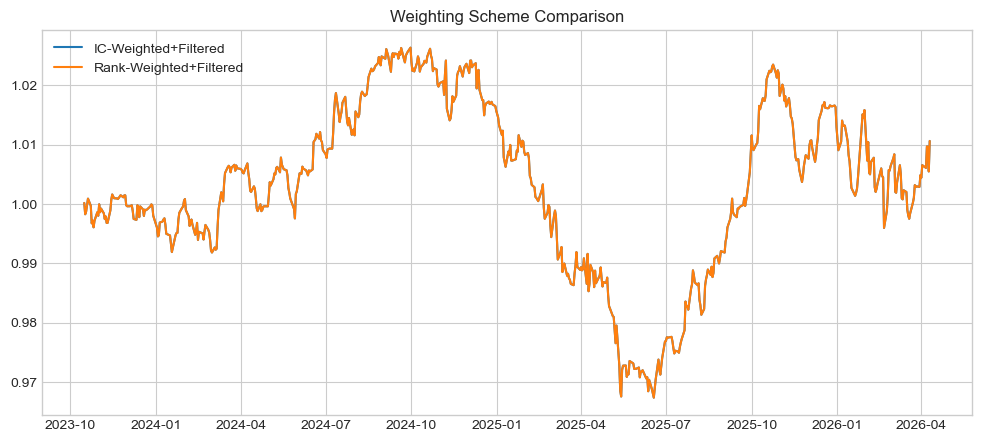

In [37]:
# --- build rank-based weights from train ---
weighted_alpha_rank = summary_train[summary_train["signal"].isin(alpha_signals_2)].copy()
weighted_alpha_rank = weighted_alpha_rank.sort_values("mean_ic", ascending=False).reset_index(drop=True)
weighted_alpha_rank["rank"] = weighted_alpha_rank.index + 1
rank_weight_map = {1: 0.50, 2: 0.30, 3: 0.20}
weighted_alpha_rank["weight"] = weighted_alpha_rank["rank"].map(rank_weight_map)
alpha_weights_rank = dict(zip(weighted_alpha_rank["signal"], weighted_alpha_rank["weight"]))
print(weighted_alpha_rank[["signal", "mean_ic", "rank", "weight"]])

# --- build weighted alpha score on test ---
rank_weighted_alpha_score = sum(alpha_library_test_2.xs(sig, level="signal", axis=1) * alpha_weights_rank[sig]
    for sig in alpha_signals_2)

# --- convert to positions ---
rank_weighted_alpha_rank = rank_weighted_alpha_score.rank(axis=1, pct=True)
long_rank = rank_weighted_alpha_rank >= 0.8
short_rank = rank_weighted_alpha_rank <= 0.2
positions_rank_weighted = long_rank.astype(int) - short_rank.astype(int)

# --- apply your winning context filter ---
positions_rank_weighted_filtered = (positions_rank_weighted * (context_rank_test_2 <= 0.6).astype(int))
rank_weighted_filtered_returns = (positions_rank_weighted_filtered.shift(1) * forward_returns_test_1d).mean(axis=1).dropna()
rank_weighted_filtered_cum = (1 + rank_weighted_filtered_returns).cumprod()
rank_weighted_filtered_sharpe = (rank_weighted_filtered_returns.mean() / rank_weighted_filtered_returns.std()) * np.sqrt(252) if rank_weighted_filtered_returns.std() != 0 else np.nan
rank_weighted_filtered_max_dd = (rank_weighted_filtered_cum / rank_weighted_filtered_cum.cummax() - 1).min()
rank_weighted_filtered_total_return = rank_weighted_filtered_cum.iloc[-1] - 1
print(f"Rank-Weighted+Filtered Sharpe: {rank_weighted_filtered_sharpe:.3f}")
print(f"Rank-Weighted+Filtered Max DD: {rank_weighted_filtered_max_dd:.2%}")
print(f"Rank-Weighted+Filtered Return: {rank_weighted_filtered_total_return:.2%}")

# --- ompare against my current best ---
plt.figure(figsize=(12, 5))
plt.plot(cum_weighted_filtered_2, label="IC-Weighted+Filtered")
plt.plot(rank_weighted_filtered_cum, label="Rank-Weighted+Filtered")
plt.legend()
plt.title("Weighting Scheme Comparison")
plt.show()

# Midpoint Conclusion 4 - IC/ rank weighted score produce identical positions

Although the IC-weighted and rank-weighted alpha combinations produced different raw score values, they generated identical cross-sectional stock rankings over the test period. 

Because the strategy converts ranked scores into hard 80/20 long-short buckets with equal position sizing, both methods resulted in identical positions and identical performance. 

This suggests that, in the current pipeline, portfolio construction is dominated by rank-based selection rather than by the exact weighting scheme.

## 21. Build continuous positions from rank

In [38]:
# --- continuous positions from weighted alpha rank ---
positions_cont = 2 * (weighted_alpha_rank_test_2 - 0.5)

# --- apply context filter ---
positions_cont_filtered = positions_cont * (context_rank_test_2 <= 0.6).astype(int)

# --- normalize daily gross exposure ---
gross = positions_cont_filtered.abs().sum(axis=1).replace(0, np.nan)
positions_cont_filtered = positions_cont_filtered.div(gross, axis=0)

# --- align returns ---
forward_returns_test_1d = make_forward_returns(prices_test, horizon=1)
forward_returns_test_1d = forward_returns_test_1d.reindex(index=positions_cont_filtered.index, columns=positions_cont_filtered.columns)

# --- portfolio returns ---
cont_returns = (positions_cont_filtered.shift(1) * forward_returns_test_1d).sum(axis=1).dropna()

# --- performance ---
cont_cum = (1 + cont_returns).cumprod()
cont_sharpe = (cont_returns.mean() / cont_returns.std()) * np.sqrt(252) if cont_returns.std() != 0 else np.nan
cont_max_dd = (cont_cum / cont_cum.cummax() - 1).min()
cont_total_ret = cont_cum.iloc[-1] - 1

print(f"Continuous Sharpe: {cont_sharpe:.3f}")
print(f"Continuous Max DD: {cont_max_dd:.2%}")
print(f"Continuous Return: {cont_total_ret:.2%}")

Continuous Sharpe: 0.359
Continuous Max DD: -15.98%
Continuous Return: 7.26%


## 22. Compare against my current best discrete strategy

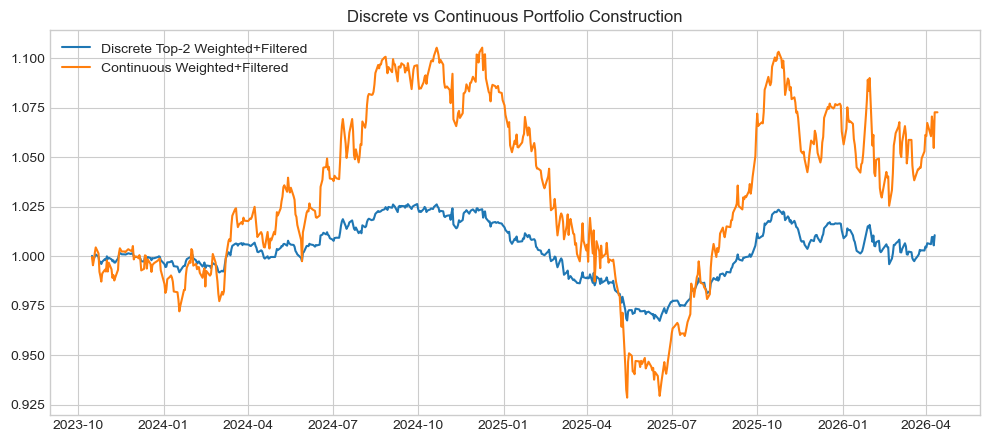

In [39]:
plt.figure(figsize=(12, 5))
plt.plot(cum_weighted_filtered_2, label="Discrete Top-2 Weighted+Filtered")
plt.plot(cont_cum, label="Continuous Weighted+Filtered")
plt.legend()
plt.title("Discrete vs Continuous Portfolio Construction")
plt.show()

# Midpoint Conclusion 5 - Moving from discrete to continuous position shows clear structural upgrade

Transitioning from discrete 80/20 portfolio construction to continuous position sizing significantly improved performance, increasing Sharpe ratio and total return. 

This demonstrates that the alpha signals contain meaningful magnitude information beyond simple ranking, and that prior performance was constrained by coarse portfolio construction. 

The results indicate that the strategy benefits from allocating capital proportionally to signal strength rather than applying equal-weighted long-short buckets, marking a shift toward a more realistic and scalable portfolio framework.

## 23. Improving a continuous strategy: Balancing return, drawdown, and turnover

Sharpe: 0.210
Max DD: -14.37%
Return: 3.74%


<Axes: title={'center': 'Continuous Strategy'}, xlabel='Date'>

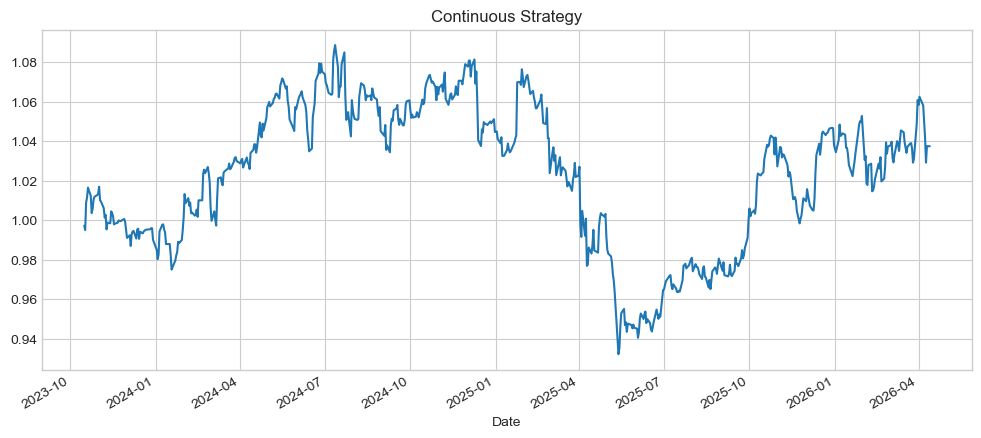

In [40]:
#--- Baseline continuous only ---
results_base = backtest_continuous_strategy(
    alpha_rank=weighted_alpha_rank_test_2,
    forward_returns=forward_returns_test_1d,
    context_rank=None,
    context_mode="none",
    position_cap=None,
    smooth_window=None,
    market_neutral=False,
    normalize_gross=True,
    target_vol=None,
    cost_per_turnover=0.0)
print(f"Sharpe: {results_base['sharpe']:.3f}")
print(f"Max DD: {results_base['max_drawdown']:.2%}")
print(f"Return: {results_base['total_return']:.2%}")
results_base["cumulative"].plot(figsize=(12, 5), title="Continuous Strategy")

In [41]:
#--- Add only the winning context ---
results_filter = backtest_continuous_strategy(
    alpha_rank=weighted_alpha_rank_test_2,
    forward_returns=forward_returns_test_1d,
    context_rank=context_rank_test_2,
    context_mode="filter",
    context_threshold=0.6,
    position_cap=None,
    smooth_window=None,
    market_neutral=False,
    normalize_gross=True,
    target_vol=None,
    cost_per_turnover=0.0)
print(f"Sharpe: {results_filter ['sharpe']:.3f}")
print(f"Max DD: {results_filter ['max_drawdown']:.2%}")
print(f"Return: {results_filter ['total_return']:.2%}")

Sharpe: 0.359
Max DD: -15.98%
Return: 7.26%


In [42]:
#--- Add position cap only ---
results_cap = backtest_continuous_strategy(
    alpha_rank=weighted_alpha_rank_test_2,
    forward_returns=forward_returns_test_1d,
    context_rank=context_rank_test_2,
    context_mode="filter",
    context_threshold=0.6,
    position_cap=0.05,
    smooth_window=None,
    market_neutral=False,
    normalize_gross=True,
    target_vol=None,
    cost_per_turnover=0.0)
print(f"Sharpe: {results_cap['sharpe']:.3f}")
print(f"Max DD: {results_cap['max_drawdown']:.2%}")
print(f"Return: {results_cap['total_return']:.2%}")

Sharpe: 0.387
Max DD: -12.28%
Return: 6.30%


In [43]:
#--- Add smoothing only ---
results_smooth = backtest_continuous_strategy(
    alpha_rank=weighted_alpha_rank_test_2,
    forward_returns=forward_returns_test_1d,
    context_rank=context_rank_test_2,
    context_mode="filter",
    context_threshold=0.6,
    position_cap=0.05,
    smooth_window=3,
    market_neutral=False,
    normalize_gross=True,
    target_vol=None,
    cost_per_turnover=0.0)
print(f"Sharpe: {results_smooth['sharpe']:.3f}")
print(f"Max DD: {results_smooth['max_drawdown']:.2%}")
print(f"Return: {results_smooth['total_return']:.2%}")

Sharpe: 0.433
Max DD: -11.61%
Return: 8.03%


In [44]:
#--- Add vol targeting ---
results_vol = backtest_continuous_strategy(
    alpha_rank=weighted_alpha_rank_test_2,
    forward_returns=forward_returns_test_1d,
    context_rank=context_rank_test_2,
    context_mode="filter",
    context_threshold=0.6,
    position_cap=0.05,
    smooth_window=3,
    market_neutral=False,
    normalize_gross=True,
    target_vol=0.10,
    vol_lookback=60,
    max_leverage_scale=2.0,
    cost_per_turnover=0.0)
print(f"Sharpe: {results_vol['sharpe']:.3f}")
print(f"Max DD: {results_vol['max_drawdown']:.2%}")
print(f"Return: {results_vol['total_return']:.2%}")

Sharpe: 0.415
Max DD: -14.53%
Return: 8.97%


In [45]:
#--- Add transaction cost ---
results_cost = backtest_continuous_strategy(
    alpha_rank=weighted_alpha_rank_test_2,
    forward_returns=forward_returns_test_1d,
    context_rank=context_rank_test_2,
    context_mode="filter",
    context_threshold=0.6,
    position_cap=0.05,
    smooth_window=3,
    market_neutral=False,
    normalize_gross=True,
    target_vol=0.10,
    vol_lookback=60,
    max_leverage_scale=2.0,
    cost_per_turnover=0.0005)
print(f"Sharpe: {results_cost['sharpe']:.3f}")
print(f"Max DD: {results_cost['max_drawdown']:.2%}")
print(f"Return: {results_cost['total_return']:.2%}")

Sharpe: -0.036
Max DD: -17.76%
Return: -2.08%


In [46]:
#--- Transaction cost analysis ---
for name, res in {
    "filter": results_filter,
    "cap": results_cap,
    "smooth": results_smooth,
    "vol": results_vol,
    "cost": results_cost,
}.items():
    avg_turnover = res["turnover"].mean()
    median_turnover = res["turnover"].median()
    annual_cost_drag = avg_turnover * 0.0005 * 252
    print(f"{name}:")
    print(f"  avg turnover   = {avg_turnover:.4f}")
    print(f"  median turnover= {median_turnover:.4f}")
    print(f"  annual cost drag ≈ {annual_cost_drag:.2%}")

filter:
  avg turnover   = 0.5875
  median turnover= 0.5660
  annual cost drag ≈ 7.40%
cap:
  avg turnover   = 0.4319
  median turnover= 0.4444
  annual cost drag ≈ 5.44%
smooth:
  avg turnover   = 0.3756
  median turnover= 0.3640
  annual cost drag ≈ 4.73%
vol:
  avg turnover   = 0.3756
  median turnover= 0.3640
  annual cost drag ≈ 4.73%
cost:
  avg turnover   = 0.3756
  median turnover= 0.3640
  annual cost drag ≈ 4.73%


# Midpoint Conclusion 6 - Transaction costs destroy all margins

Although the strategy demonstrates strong gross performance, turnover remains elevated (~35–60% daily), resulting in an estimated annual cost drag of 4.7%–7.4%. 

This effectively eliminates most of the alpha after realistic transaction costs. Smoothing and position caps reduce turnover meaningfully, but not sufficiently. 

The primary limitation is therefore execution frequency rather than signal quality. The next step is to reduce turnover through lower rebalance frequency, stronger smoothing, and trade filtering mechanisms.

## 24. Fine-tuning parameters to improve performance

In [47]:
rebalance_list = [1, 3, 5, 7, 10, 14, 21, 28]
smooth_list = [1, 3, 5, 7, 10, 14, 21, 28]
min_trade_threshold_list = [0.0, 0.01, 0.02]
position_cap_list = [None, 0.03, 0.05]
results = []
for rb in rebalance_list:
    for sm in smooth_list:
        for th in min_trade_threshold_list:
            for cap in position_cap_list:
                res = backtest_continuous_strategy(
                    alpha_rank=weighted_alpha_rank_test_2,
                    forward_returns=forward_returns_test_1d,
                    context_rank=context_rank_test_2,
                    context_mode="filter",
                    context_threshold=0.6,
                    position_cap=cap,
                    smooth_window=sm,
                    rebalance_every=rb,
                    min_trade_threshold=th,
                    market_neutral=False,
                    normalize_gross=True,
                    target_vol=0.10,
                    vol_lookback=60,
                    max_leverage_scale=2.0,
                    cost_per_turnover=0.0005)
                
                results.append({
                    "rb": rb,
                    "smooth": sm,
                    "threshold": th,
                    "cap": cap,
                    "sharpe": res["sharpe"],
                    "max_dd": res["max_drawdown"],
                    "return": res["total_return"]})
                
results = pd.DataFrame(results)
results = results.sort_values("sharpe", ascending=False).reset_index(drop=True)
print(results.head(20))

    rb  smooth  threshold   cap    sharpe    max_dd    return
0   21       7       0.00  0.05  1.341139 -0.088761  0.353674
1   21       7       0.00  0.03  1.341139 -0.088761  0.353674
2   21       7       0.02  0.03  1.332288 -0.088159  0.350784
3   21       7       0.01  0.05  1.331620 -0.089090  0.350676
4   21       7       0.02  0.05  1.315878 -0.086126  0.345420
5   21       7       0.01  0.03  1.315878 -0.086126  0.345420
6   21       7       0.02   NaN  1.268698 -0.095972  0.331152
7   21       7       0.01   NaN  1.268623 -0.096003  0.331129
8   21       7       0.00   NaN  1.268088 -0.096008  0.330964
9   21       3       0.00   NaN  1.207474 -0.071729  0.301808
10  21       3       0.02   NaN  1.207474 -0.071729  0.301808
11  21       3       0.01   NaN  1.207474 -0.071729  0.301808
12   7      14       0.02  0.03  1.146164 -0.101693  0.290100
13  21       1       0.00   NaN  1.145431 -0.079478  0.281655
14  21       1       0.01   NaN  1.145431 -0.079478  0.281655
15  21  

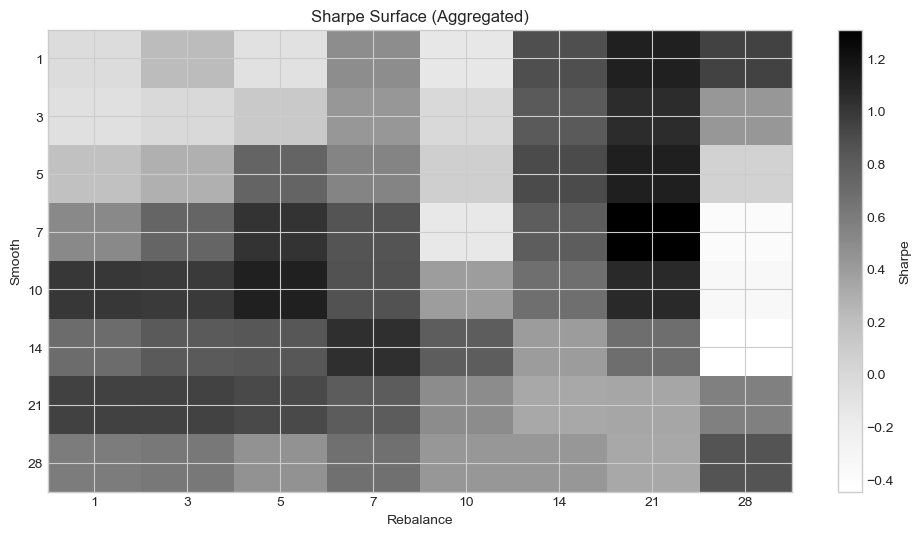

In [48]:
pivot = results.groupby(["smooth", "rb"])["sharpe"].mean().unstack()
plt.figure(figsize=(12,6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Sharpe")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("Rebalance")
plt.ylabel("Smooth")
plt.title("Sharpe Surface (Aggregated)")
plt.show()

In [49]:
local_rb_list = [18, 21, 24, 28]
local_smooth_list = [5, 7, 10, 14]
local_results = []
for rb in local_rb_list:
    for sm in local_smooth_list:
        res = backtest_continuous_strategy(
            alpha_rank=weighted_alpha_rank_test_2,
            forward_returns=forward_returns_test_1d,
            context_rank=context_rank_test_2,
            context_mode="filter",
            context_threshold=0.6,
            rebalance_every=rb,
            smooth_window=sm,
            min_trade_threshold=0.00,
            position_cap=0.05,
            market_neutral=False,
            normalize_gross=True,
            target_vol=0.10,
            vol_lookback=60,
            max_leverage_scale=2.0,
            cost_per_turnover=0.0005)

        local_results.append({
            "rb": rb,
            "smooth": sm,
            "sharpe": res["sharpe"],
            "max_dd": res["max_drawdown"],
            "return": res["total_return"],
            "avg_turnover": res["turnover"].mean(),
            "annual_cost_drag": res["turnover"].mean() * 0.0005 * 252})

local_results = pd.DataFrame(local_results).sort_values("sharpe", ascending=False)
print(local_results)

    rb  smooth    sharpe    max_dd    return  avg_turnover  annual_cost_drag
5   21       7  1.341139 -0.088761  0.353674      0.061803          0.007787
4   21       5  1.141313 -0.089347  0.288177      0.059177          0.007456
6   21      10  1.062112 -0.133964  0.268711      0.063450          0.007995
7   21      14  0.666081 -0.119842  0.153871      0.061944          0.007805
9   24       7  0.616210 -0.157655  0.142511      0.050836          0.006405
8   24       5  0.551390 -0.137832  0.124890      0.049092          0.006186
10  24      10  0.428805 -0.156592  0.093083      0.052874          0.006662
11  24      14  0.320165 -0.118129  0.065173      0.053120          0.006693
1   18       7  0.259482 -0.126564  0.048904      0.071520          0.009011
0   18       5  0.149030 -0.103857  0.022663      0.071262          0.008979
3   18      14  0.087840 -0.141391  0.008428      0.072826          0.009176
12  28       5  0.061216 -0.141336  0.002311      0.043469          0.005477

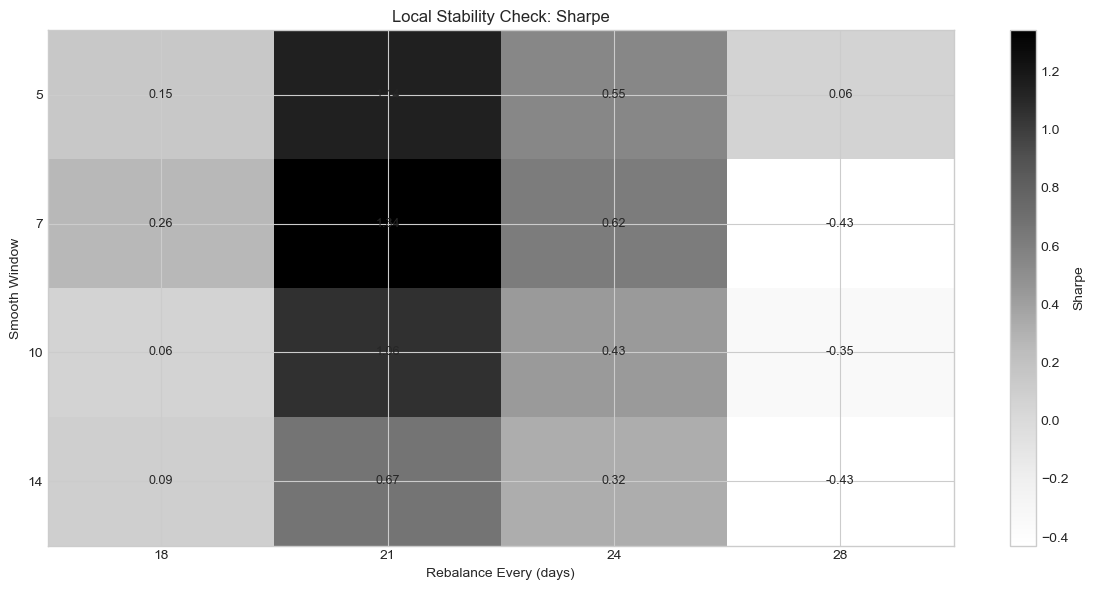

In [50]:
pivot_sharpe = local_results.pivot(index="smooth", columns="rb", values="sharpe").sort_index()

plt.figure(figsize=(12, 6))
plt.imshow(pivot_sharpe.values, aspect="auto")
plt.colorbar(label="Sharpe")

plt.xticks(range(len(pivot_sharpe.columns)), pivot_sharpe.columns)
plt.yticks(range(len(pivot_sharpe.index)), pivot_sharpe.index)

plt.xlabel("Rebalance Every (days)")
plt.ylabel("Smooth Window")
plt.title("Local Stability Check: Sharpe")
for i in range(pivot_sharpe.shape[0]):
    for j in range(pivot_sharpe.shape[1]):
        val = pivot_sharpe.iloc[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 25. Out-of-sample split / rolling validation

Mean Sharpe: 2.647826541337356
Median Sharpe: 2.131512914635568


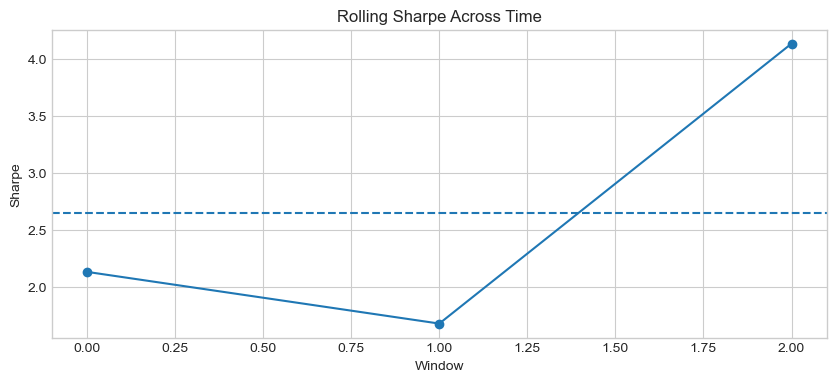

In [51]:
#-- use shared rolling windows from src.utils --
#-- run rolling backtest --
windows = generate_rolling_windows(
    index=weighted_alpha_rank_test_2.index,
    train_size=252,
    test_size=189,
    step_size=63,
    purge_size=1,
    embargo_size=0)
rolling_results = []
for i, (train_idx, test_idx) in enumerate(windows):
    alpha_test = weighted_alpha_rank_test_2.loc[test_idx]
    forward_returns_test_window = forward_returns_test_1d.loc[test_idx]
    context_test = context_rank_test_2.loc[test_idx]
    res = backtest_continuous_strategy(
        alpha_rank=alpha_test,
        forward_returns=forward_returns_test_window,
        context_rank=context_test,
        context_mode="filter",
        context_threshold=0.6,
        rebalance_every=21,
        smooth_window=7,
        min_trade_threshold=0.00,
        position_cap=0.05,
        market_neutral=False,
        normalize_gross=True,
        target_vol=0.10,
        vol_lookback=60,
        max_leverage_scale=2.0,
        cost_per_turnover=0.0005)
    rolling_results.append({
        "window": i,
        "sharpe": res["sharpe"],
        "max_dd": res["max_drawdown"],
        "return": res["total_return"],
        "avg_turnover": res["turnover"].mean()})
rolling = pd.DataFrame(rolling_results)
rolling["raw_sharpe"] = rolling["sharpe"] / np.sqrt(252)    
print("Mean Sharpe:", rolling["sharpe"].mean())
print("Median Sharpe:", rolling["sharpe"].median())

#-- visualize stability --
plt.figure(figsize=(10,4))
plt.plot(rolling["window"], rolling["sharpe"], marker="o")
plt.axhline(rolling["sharpe"].mean(), linestyle="--")

plt.title("Rolling Sharpe Across Time")
plt.xlabel("Window")
plt.ylabel("Sharpe")
plt.show()

## 26. Full dataset walk-forward validation

In [52]:
alpha_library_full_2 = select_signals(signal_library, alpha_signals_2)
context_library_full_2 = select_signals(signal_library, context_signals_2)
forward_returns_full_1d = make_forward_returns(clean_close_prices, horizon=1)

windows = generate_rolling_windows(
    index=clean_close_prices.index,
    train_size=504,
    test_size=126,
    step_size=126,
    purge_size=1,
    embargo_size=0)

walkforward_results = []

for i, (train_idx, test_idx) in enumerate(windows):
    alpha_train = alpha_library_full_2.loc[train_idx]
    alpha_test = alpha_library_full_2.loc[test_idx]
    context_test = context_library_full_2.loc[test_idx]

    fwd_train = forward_returns_full_1d.loc[train_idx]
    fwd_test = forward_returns_full_1d.loc[test_idx]

    weight_df = compute_ic_weights(
        alpha_library=alpha_train,
        forward_returns=fwd_train,
        alpha_signals=alpha_signals_2,
        score_signal_library_func=score_signal_library,
        summarize_signal_names_func=summarize_signal_names,
        min_obs=60)

    alpha_weights = dict(zip(weight_df["signal"], weight_df["weight"]))

    alpha_rank_test = build_weighted_alpha_rank(
        alpha_library=alpha_test,
        weights=alpha_weights)

    context_rank_test = build_context_rank(
        context_library=context_test,
        context_signals=context_signals_2)

    res = backtest_continuous_strategy(
        alpha_rank=alpha_rank_test,
        forward_returns=fwd_test,
        context_rank=context_rank_test,
        context_mode="filter",
        context_threshold=0.6,
        position_cap=0.05,
        smooth_window=7,
        rebalance_every=21,
        min_trade_threshold=0.00,
        market_neutral=False,
        normalize_gross=True,
        target_vol=0.10,
        vol_lookback=60,
        max_leverage_scale=2.0,
        cost_per_turnover=0.0005)

    walkforward_results.append({
        "window": i,
        "train_start": train_idx[0],
        "train_end": train_idx[-1],
        "test_start": test_idx[0],
        "test_end": test_idx[-1],
        "n_signals": len(alpha_weights),
        "sharpe": res["sharpe"],
        "max_dd": res["max_drawdown"],
        "return": res["total_return"],
        "avg_turnover": res["turnover"].mean()})

walkforward = pd.DataFrame(walkforward_results)
walkforward = walkforward.copy()
walkforward["sharpe"] = walkforward["sharpe"].round(3)
walkforward["max_dd"] = walkforward["max_dd"].round(3)
walkforward["return"] = walkforward["return"].round(3)
walkforward["avg_turnover"] = walkforward["avg_turnover"].round(3)
walkforward


,window,train_start,train_end,test_start,test_end,n_signals,sharpe,max_dd,return,avg_turnover
0,0,2018-01-02,2020-01-02,2020-01-03,2020-07-02,3,0.018,-0.018,-0.000,0.052
1,1,2018-07-03,2020-07-02,2020-07-06,2020-12-31,3,0.055,-0.058,0.000,0.052
2,2,2019-01-03,2020-12-31,2021-01-04,2021-07-02,3,2.194,-0.024,0.052,0.055
3,3,2019-07-05,2021-07-02,2021-07-06,2021-12-31,3,1.132,-0.045,0.037,0.059
4,4,2020-01-03,2021-12-31,2022-01-03,2022-07-05,3,-1.192,-0.069,-0.032,0.053
5,5,2020-07-06,2022-07-05,2022-07-06,2023-01-03,3,-0.881,-0.044,-0.017,0.053
6,6,2021-01-04,2023-01-03,2023-01-04,2023-07-06,3,3.044,-0.021,0.073,0.053
7,7,2021-07-06,2023-07-06,2023-07-07,2024-01-04,3,1.263,-0.071,0.037,0.052
8,8,2022-01-03,2024-01-04,2024-01-05,2024-07-08,3,-2.218,-0.086,-0.071,0.051
9,9,2022-07-06,2024-07-08,2024-07-09,2025-01-06,3,0.638,-0.059,0.016,0.055


In [53]:
summary = {"Mean Sharpe": round(walkforward["sharpe"].mean(), 3),
           "Median Sharpe": round(walkforward["sharpe"].median(), 3),
           "Mean Return (%)": round(walkforward["return"].mean() * 100, 2),
           "Median Return (%)": round(walkforward["return"].median() * 100, 2),
           "Worst Drawdown (%)": round(walkforward["max_dd"].min() * 100, 2),
           "Positive Return Windows (%)": round((walkforward["return"] > 0).mean() * 100, 1),
           "Positive Sharpe Windows (%)": round((walkforward["sharpe"] > 0).mean() * 100, 1)}
for k, v in summary.items():
    print(f"{k}: {v}")

Mean Sharpe: 0.427
Median Sharpe: 0.347
Mean Return (%): 0.99
Median Return (%): 0.8
Worst Drawdown (%): -8.6
Positive Return Windows (%): 50.0
Positive Sharpe Windows (%): 66.7


# Midpoint Conclusion 7 - Signals are real and repeatable, but execution is the bottleneck

The walk-forward evaluation shows that the strategy maintains a positive and consistent edge across time, with mean and median Sharpe ratios of 0.427 and 0.347 respectively. The close alignment between mean and median returns indicates that performance is not driven by isolated outliers, but rather reflects a stable distribution of outcomes.

However, only 50% of test windows achieve positive returns despite 66.7% having positive Sharpe ratios, suggesting that while the signal is directionally informative, its monetization is constrained by noise and transaction costs.

Overall, the results support the existence of a genuine predictive signal, but also highlight the need for improved execution efficiency and better alignment between signal horizon and trading frequency.

# Conclusion

In this notebook, I built a systematic signal discovery and validation pipeline, replacing intuition with structured testing. I identified a small set of robust alpha signals and showed that context signals act best as modifiers rather than standalone drivers. Moving from discrete to continuous portfolio construction improved performance, but also revealed that transaction costs are the primary constraint.

Through execution tuning (smoothing, rebalance, position caps), I reduced turnover and stabilized results. A full walk-forward validation confirmed a consistent but moderate edge (mean Sharpe ~0.43), though performance remains somewhat regime-dependent.

Overall, this establishes a credible baseline: the signal is real, but not yet fully optimized or scalable.

In [54]:
import json
project_root = Path.cwd().parent
config_dir = project_root / "config"
outputs_dir = project_root / "outputs"
data_dir = project_root / "data" / "processed"

config_dir.mkdir(parents=True, exist_ok=True)
outputs_dir.mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)

ALPHA_SIGNALS = alpha_signals_2
CONTEXT_SIGNALS = context_signals_2
with open(config_dir / "alpha_signals.json", "w") as f:
    json.dump(ALPHA_SIGNALS, f, indent=2)
with open(config_dir / "context_signals.json", "w") as f:
    json.dump(CONTEXT_SIGNALS, f, indent=2)
print("✅ Saved signal lists")

STRATEGY_CONFIG = {"rebalance_every": 21,
                   "smooth_window": 7,
                   "context_threshold": 0.6,
                   "position_cap": 0.05,
                   "target_vol": 0.10,
                   "max_leverage_scale": 2.0}
with open(config_dir / "strategy_config.json", "w") as f:
    json.dump(STRATEGY_CONFIG, f, indent=2)
print("✅ Saved strategy config")

try:
    alpha_library_full_2.to_parquet(data_dir / "alpha_library.parquet")
    context_library_full_2.to_parquet(data_dir / "context_library.parquet")
    print("✅ Saved signal libraries")
except Exception as e:
    print("⚠️ Skipped saving signal libraries:", e)

try:
    walkforward.to_csv(outputs_dir / "walkforward_results.csv", index=False)
    print("✅ Saved walk-forward results")
except Exception as e:
    print("⚠️ Skipped walk-forward results:", e)

try:
    results.to_csv(outputs_dir / "grid_search_results.csv", index=False)
    print("✅ Saved grid search results")
except Exception as e:
    print("⚠️ Skipped grid search results:", e)






✅ Saved signal lists
✅ Saved strategy config
✅ Saved signal libraries
✅ Saved walk-forward results
✅ Saved grid search results
